In [105]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from RetinaFace import RetinaFace
from ArcFace import ArcFace
from identify import Gallery

In [106]:
retina = RetinaFace(ctx_id=-1)
arcface = ArcFace(ctx_id=-1)
gallery = Gallery()

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


found 300 snapshots
../volumes_backup/snapshots/03c4b1e4-189f-452a-bc2e-2d9bc9c5e15c.jpg
detected 1 face(s)
bbox=[ 920.25183  386.02325 1007.09454  497.2683 ] det_score=0.824 -> MReza (score=0.564)


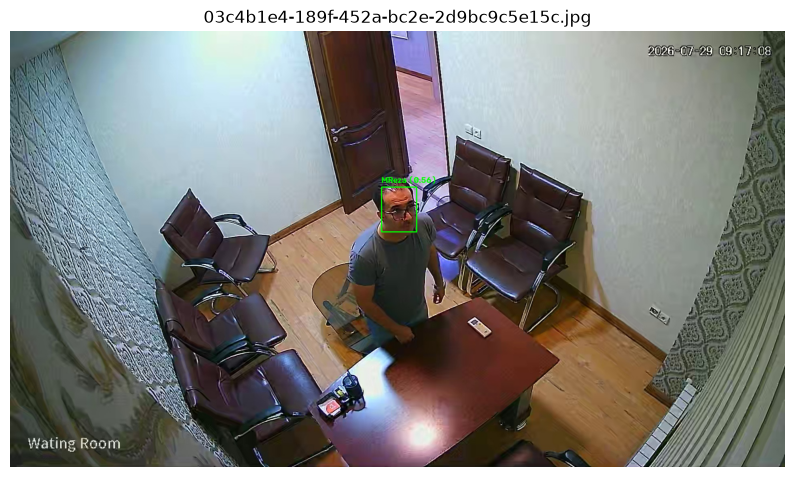

In [113]:
snapshots_dir = Path("../volumes_backup/goldenset_images")
image_paths = list(snapshots_dir.glob("*.jpg"))
print(f"found {len(image_paths)} snapshots")

# image_path = random.choice(image_paths)
image_path = Path("../volumes_backup/snapshots/03c4b1e4-189f-452a-bc2e-2d9bc9c5e15c.jpg")


print(image_path)

image = cv2.imread(str(image_path))
assert image is not None, f"failed to read {image_path}"




faces = retina.detect(image)
print(f"detected {len(faces)} face(s)")

matches = []
for face in faces:
    aligned = retina.align(image, face.kps)
    embedding = arcface.embed(aligned)
    match = gallery.identify(embedding)
    matches.append(match)
    print(f"bbox={face.bbox} det_score={face.det_score:.3f} -> {match.label} (score={match.score:.3f})")
    
    
    

vis = image.copy()
for face, match in zip(faces, matches):
    x1, y1, x2, y2 = face.bbox.astype(int)
    color = (0, 255, 0) if match.label != "unknown" else (0, 0, 255)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
    label = f"{match.label} ({match.score:.2f})"
    cv2.putText(
        vis,
        label,
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2,
    )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(image_path.name)
plt.show()

## Presentation Images

Run detection + identification over every image in `Presentation_Images/` and save the annotated results to `Presentation_Images/results/`.

In [3]:
presentation_dir = Path("../volumes_backup/Presentation_Images")
results_dir = presentation_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

presentation_paths = sorted(
    p for p in presentation_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
print(f"found {len(presentation_paths)} presentation images")

for image_path in presentation_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"failed to read {image_path}, skipping")
        continue

    faces = retina.detect(image)

    matches = []
    for face in faces:
        aligned = retina.align(image, face.kps)
        embedding = arcface.embed(aligned)
        match = gallery.identify(embedding)
        matches.append(match)

    vis = image.copy()
    for face, match in zip(faces, matches):
        x1, y1, x2, y2 = face.bbox.astype(int)
        color = (0, 255, 0) if match.label != "unknown" else (0, 0, 255)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        label = f"{match.label} ({match.score:.2f})"
        cv2.putText(
            vis,
            label,
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2,
        )

    out_path = results_dir / image_path.name
    cv2.imwrite(str(out_path), vis)
    print(f"{image_path.name}: {len(faces)} face(s) -> {out_path}")

found 18 presentation images


/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


00cb553f-3545-424a-a12c-c9dea40ea1ec.jpg: 2 face(s) -> ../volumes_backup/Presentation_Images/results/00cb553f-3545-424a-a12c-c9dea40ea1ec.jpg
0a37bf87-9e1a-4746-b1b0-8337acebb0fc.jpg: 0 face(s) -> ../volumes_backup/Presentation_Images/results/0a37bf87-9e1a-4746-b1b0-8337acebb0fc.jpg
0b311157-4ea4-4791-956e-f404c2a8a987.jpg: 1 face(s) -> ../volumes_backup/Presentation_Images/results/0b311157-4ea4-4791-956e-f404c2a8a987.jpg
f05696b5-cb4e-4c88-8e05-ba44bdb86340.jpg: 1 face(s) -> ../volumes_backup/Presentation_Images/results/f05696b5-cb4e-4c88-8e05-ba44bdb86340.jpg
fa13e4cd-bb59-4c63-a304-8a9c3f1c03ef.jpg: 1 face(s) -> ../volumes_backup/Presentation_Images/results/fa13e4cd-bb59-4c63-a304-8a9c3f1c03ef.jpg
fb9fe821-36cf-4e9f-9547-d96668994e63.jpg: 1 face(s) -> ../volumes_backup/Presentation_Images/results/fb9fe821-36cf-4e9f-9547-d96668994e63.jpg
fc0c9d95-ddc6-45c8-9899-1b85e8c26984.jpg: 2 face(s) -> ../volumes_backup/Presentation_Images/results/fc0c9d95-ddc6-45c8-9899-1b85e8c26984.jpg
fd6190